# **Exploration study**

Exploration study of the variables envolved

## Preparing data

In [2]:
import json
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

with open('./dataset_task1_exist2025/training.json', 'r', encoding='utf-8') as file:
    training_dict = json.load(file)

VARIABLES_TO_ANALYZE = ["lang", "gender_annotators", "age_annotators", "ethnicities_annotators", "study_levels_annotators", "countries_annotators", "labels_task1"]

freq_vars = {var: {} for var in VARIABLES_TO_ANALYZE}
ordered_data = {var: [] for var in VARIABLES_TO_ANALYZE}
for key in training_dict.keys():
    for var in VARIABLES_TO_ANALYZE:
        value = training_dict[key][var]
        # Frequency count
        if isinstance(value, list):
            for item in value:
                freq_vars[var][item] = freq_vars[var].get(item, 0) + 1
                ordered_data[var].append(item)
        else:
            freq_vars[var][value] = freq_vars[var].get(value, 0) + 1
            ordered_data[var] += [value] * len(training_dict[key]["annotators"])

## Frequency graphics

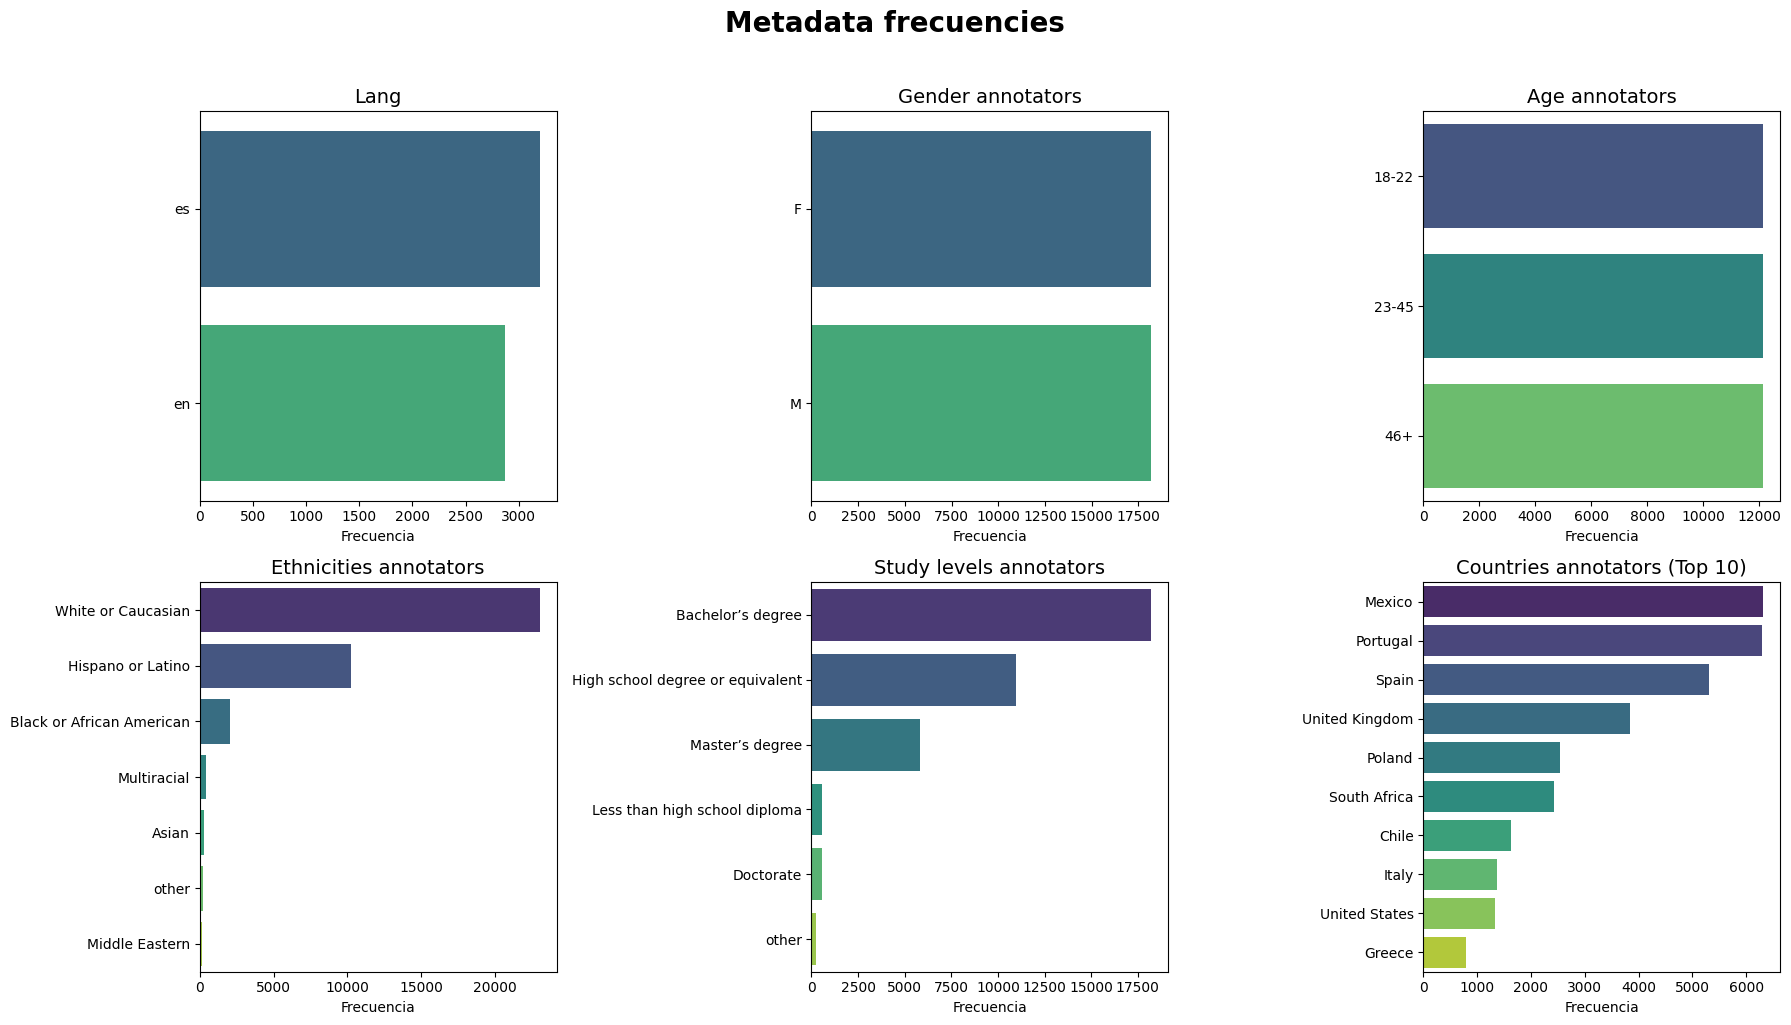

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle('Metadata frecuencies', fontsize=20, fontweight='bold', y=1.02)
axes_flat = axes.flatten()

for i, (var_name, values) in enumerate(freq_vars.items()):
    if var_name == "labels_task1":
        continue
    # Sort data
    sorted_data = dict(sorted(values.items(), key=lambda item: item[1], reverse=True))
    
    # Limit to to 10 most frequent categories
    if len(sorted_data) > 10:
        sorted_data = dict(list(sorted_data.items())[:10])
        title_suffix = " (Top 10)"
    else:
        title_suffix = ""

    categories = list(sorted_data.keys())
    counts = list(sorted_data.values())

    # Graphic
    sns.barplot(x=counts, y=categories, ax=axes_flat[i], palette="viridis", hue=categories, legend=False)
    axes_flat[i].set_title(f"{var_name.replace('_', ' ').capitalize()}{title_suffix}", fontsize=14)
    axes_flat[i].set_xlabel("Frecuencia")
    axes_flat[i].set_ylabel("")

plt.tight_layout()
plt.show()

## Correlation analysis language-label

In [ ]:
# Pandas Dataframe
df = pd.DataFrame({
    'lang': ordered_data["lang"],
    'labels': ordered_data["labels_task1"]
})

contingency_table = pd.crosstab(df['lang'], df['labels'])
# Chi2
chi2, p, dof, expected = chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1

# Avoid / 0 in Cramer's V
if min_dim == 0:
    v_cramer = 0
else:
    v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}, Cramer's V: {v_cramer:.4f}")

porcentage_table = pd.crosstab(df['lang'], df['labels'], normalize='index') * 100
print(porcentage_table)

Chi2: 212.9335, p-value: 0.0000, Cramer's V: 0.0765
labels         NO        YES
lang                        
en      59.529617  40.470383
es      51.909831  48.090169


A statistically significant dependence was observed between language and label (p < 0.05). English showed a greater tendency towards the 'NO' label (59.5%) compared to Spanish (51.9%). However, the strength of this association was weak (Cramer's V = 0.0765), indicating that language was not the main factor determining the prediction.

## Correlation analysis gender_annotators-label

In [8]:
# Pandas Dataframe
df = pd.DataFrame({
    'gender_annotators': ordered_data["gender_annotators"],
    'labels': ordered_data["labels_task1"]
})

contingency_table = pd.crosstab(df['gender_annotators'], df['labels'])
# Chi2
chi2, p, dof, expected = chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1

# Avoid / 0 in Cramer's V
if min_dim == 0:
    v_cramer = 0
else:
    v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}, Cramer's V: {v_cramer:.4f}")

porcentage_table = pd.crosstab(df['gender_annotators'], df['labels'], normalize='index') * 100
print(porcentage_table)

Chi2: 1.4464, p-value: 0.2291, Cramer's V: 0.0063
labels                    NO        YES
gender_annotators                      
F                  55.200088  44.799912
M                  55.832234  44.167766


In [10]:
for var in VARIABLES_TO_ANALYZE:
    # Pandas Dataframe
    df = pd.DataFrame({
        var: ordered_data[var],
        'labels': ordered_data["labels_task1"]
    })

    contingency_table = pd.crosstab(df[var], df['labels'])
    # Chi2
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1

    # Avoid / 0 in Cramer's V
    if min_dim == 0:
        v_cramer = 0
    else:
        v_cramer = np.sqrt(chi2 / (n * min_dim))

    print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}, Cramer's V: {v_cramer:.4f}")

    porcentage_table = pd.crosstab(df[var], df['labels'], normalize='index') * 100
    print(porcentage_table)

Chi2: 212.9335, p-value: 0.0000, Cramer's V: 0.0765
labels         NO        YES
lang                        
en      59.529617  40.470383
es      51.909831  48.090169
Chi2: 1.4464, p-value: 0.2291, Cramer's V: 0.0063
labels                    NO        YES
gender_annotators                      
F                  55.200088  44.799912
M                  55.832234  44.167766
Chi2: 34.4169, p-value: 0.0000, Cramer's V: 0.0308
labels                 NO        YES
age_annotators                      
18-22           57.659960  42.340040
23-45           54.205145  45.794855
46+             54.683377  45.316623
Chi2: 45.8409, p-value: 0.0000, Cramer's V: 0.0355
labels                            NO        YES
ethnicities_annotators                         
Asian                      56.065574  43.934426
Black or African American  59.614458  40.385542
Hispano or Latino          53.461388  46.538612
Middle Eastern             55.172414  44.827586
Multiracial                47.901235  52.098765